# Verification of the Business Logic of the Model (Deep-Dive SHAP)

**Goal:** The purpose of this notebook is to perform a detailed explainability analysis of the advanced model (XGBoost). We want to check whether the model "thinks" logically and whether the rules it learned make sense from the business perspective of Nocarz.

We will examine this using:
1. **Dependence plots:** These will show how changing a specific value (e.g., price or lead time) affects the prediction.
2. **Local explainability (Waterfall plots):** A simulation of what exactly a Nocarz consultant would see for an individual customer.

In [13]:
import pandas as pd
import xgboost as xgb
import shap
import joblib
import matplotlib.pyplot as plt

# Ensuring plots will be readable
shap.initjs()

# 1. Loading model and data (taking a random sample so plots render quickly)
print("Loading model and data...")
model_advanced = joblib.load('../src/models/model_advanced.joblib')

df = pd.read_csv('../data/processed/processed_data.csv').astype(float)
X = df.drop('is_long_stay', axis=1)

# For deep analysis, we take a representative sample of 2000 observations
X_sample = X.sample(n=2000, random_state=42)

# 2. Generating SHAP values using the newer API (returns an Explanation object)
print("Computing SHAP values (this may take a few seconds)...")
explainer = shap.TreeExplainer(model_advanced)
shap_values = explainer(X_sample)

print("Done. Proceeding to analysis.")

Loading model and data...
Computing SHAP values (this may take a few seconds)...
Done. Proceeding to analysis.


## 1. Global Analysis - Reminder of Key Criteria

Let's take another look at the distribution of the most important features. A `beeswarm` plot is an improved version of a scatter plot – it precisely shows the density of customers.

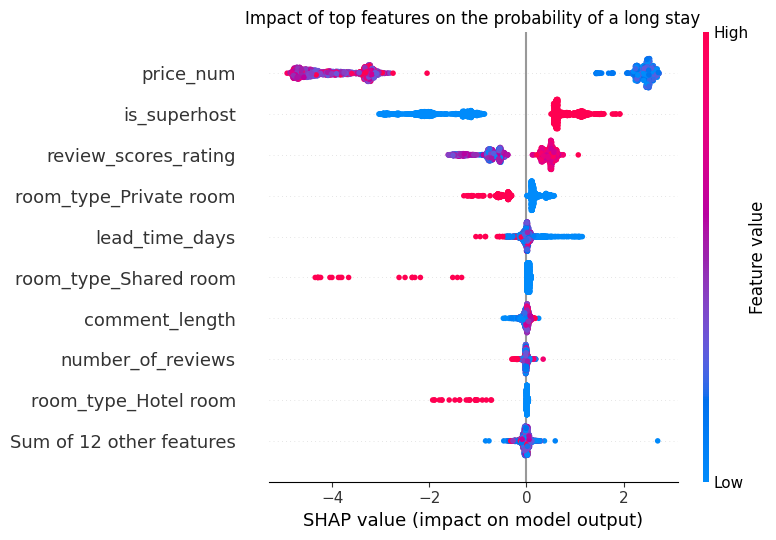

In [14]:
plt.figure(figsize=(10, 6))
shap.plots.beeswarm(shap_values, max_display=10, show=False)
plt.title("Impact of top features on the probability of a long stay")
plt.tight_layout()
plt.savefig('../results/shap_beeswarm.png', bbox_inches='tight')
plt.show()

## 2. Dependence Plots - Does the Model Make Sense?

In this section, we examine so-called non-linearity and cutoff points. Let's focus on the most important feature, e.g., `lead_time_days` (the advance notice with which the reservation was made).

*Business Expectation:* Reservations made with very long advance notice (e.g., >90 days) should drastically increase the probability of a long stay (these are often business trips or planned summer-long migrations).

<Figure size 800x500 with 0 Axes>

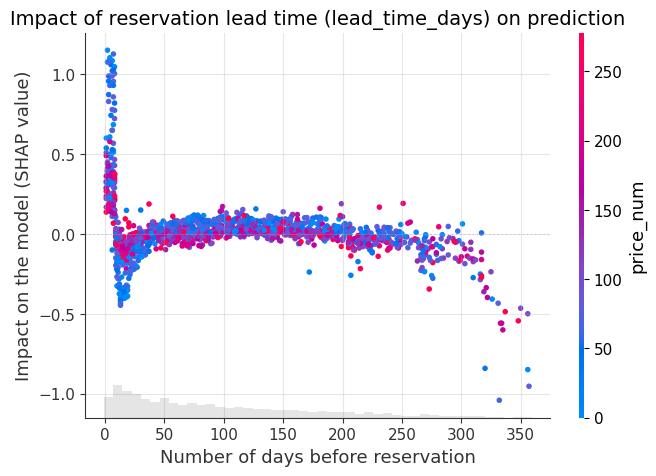

<Figure size 800x500 with 0 Axes>

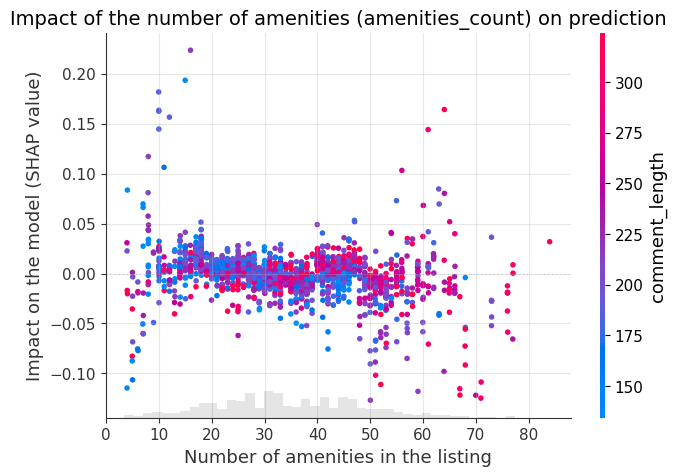

<Figure size 800x500 with 0 Axes>

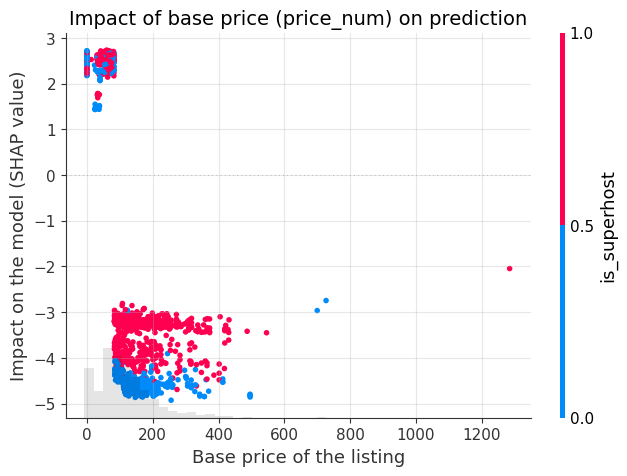

In [15]:
# 1. Analysis of the impact of reservation lead time (lead_time_days)
plt.figure(figsize=(8, 5))
shap.plots.scatter(shap_values[:, "lead_time_days"], color=shap_values, show=False)
plt.title("Impact of reservation lead time (lead_time_days) on prediction", fontsize=14)
plt.xlabel("Number of days before reservation")
plt.ylabel("Impact on the model (SHAP value)")
plt.grid(alpha=0.3)
plt.savefig('../results/shap_scatter_lead_time.png', bbox_inches='tight')
plt.show()
plt.close()

# 2. Analysis of the impact of the number of amenities (amenities_count)
plt.figure(figsize=(8, 5))
shap.plots.scatter(shap_values[:, "amenities_count"], color=shap_values, show=False)
plt.title("Impact of the number of amenities (amenities_count) on prediction", fontsize=14)
plt.xlabel("Number of amenities in the listing")
plt.ylabel("Impact on the model (SHAP value)")
plt.grid(alpha=0.3)
plt.savefig('../results/shap_scatter_amenities.png', bbox_inches='tight')
plt.show()
plt.close()

# 3. Analysis of the impact of base price (price_num)
plt.figure(figsize=(8, 5))
shap.plots.scatter(shap_values[:, "price_num"], color=shap_values, show=False)
plt.title("Impact of base price (price_num) on prediction", fontsize=14)
plt.xlabel("Base price of the listing")
plt.ylabel("Impact on the model (SHAP value)")
plt.grid(alpha=0.3)
plt.savefig('../results/shap_scatter_price.png', bbox_inches='tight')
plt.show()
plt.close()

## 3. Local Explainability (Simulation for Nocarz Consultant)

This is the most important proof of system functionality. Let's select two extreme cases from our sample (one customer who wants to rent short-term, and another looking for a long-term stay). The waterfall plot will show exactly how features "push" the probability from the base value to the final decision.

--- CASE 1: ALMOST CERTAIN LONG STAY (Probability: 99.48% ) ---
The plot shows which specific feature values of this customer convinced the model of this decision:


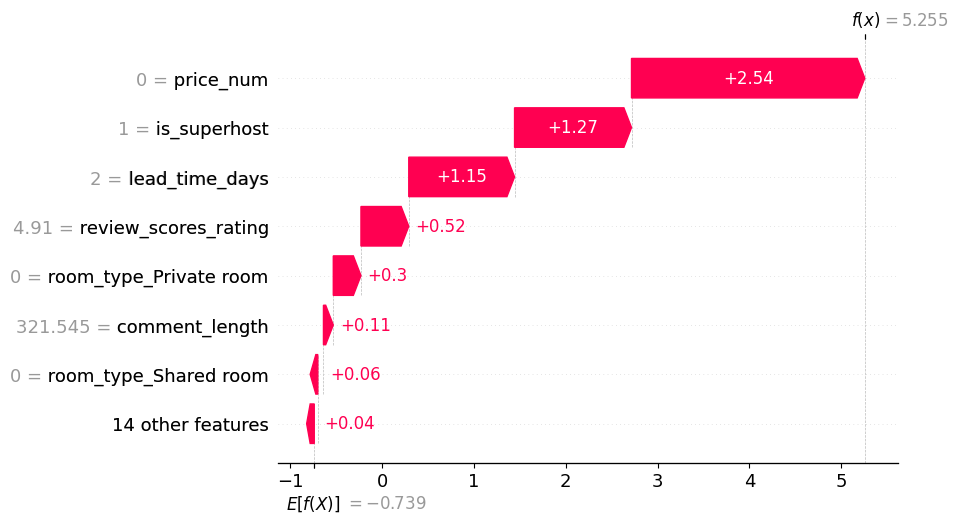


--- CASE 2: TYPICAL SHORT STAY (Probability: 0.02% ) ---
The plot shows what made the model classify this stay as short-term:


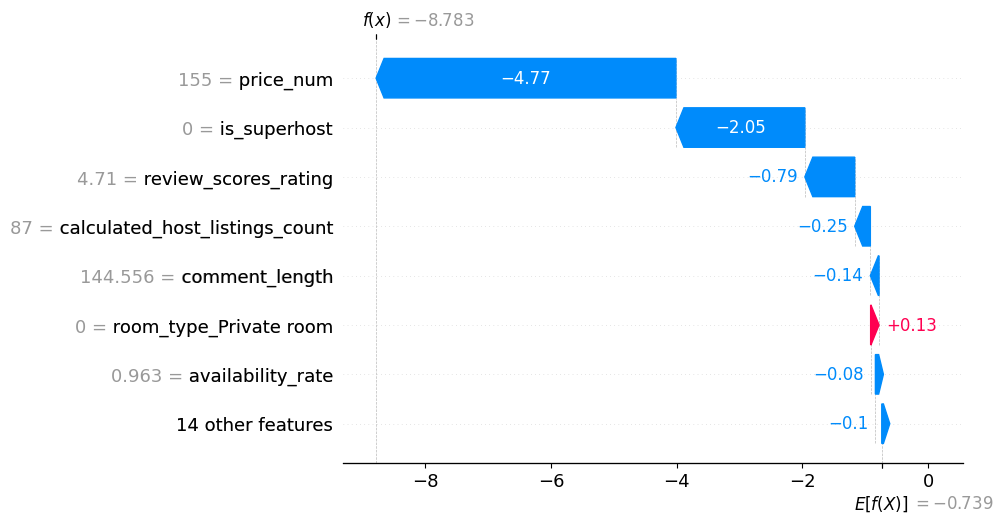

In [16]:
# Find indices with highest and lowest predicted probability in the sample
preds = model_advanced.predict_proba(X_sample)[:, 1]
idx_long_stay = preds.argmax()
idx_short_stay = preds.argmin()

print(f"--- CASE 1: ALMOST CERTAIN LONG STAY (Probability: {preds[idx_long_stay]:.2%} ) ---")
print("The plot shows which specific feature values of this customer convinced the model of this decision:")
shap.plots.waterfall(shap_values[idx_long_stay], max_display=8, show=True)

print(f"\n--- CASE 2: TYPICAL SHORT STAY (Probability: {preds[idx_short_stay]:.2%} ) ---")
print("The plot shows what made the model classify this stay as short-term:")
shap.plots.waterfall(shap_values[idx_short_stay], max_display=8, show=True)

## Business Conclusions from SHAP Analysis

Based on the above plots (in particular the Scatter dependence plots), we can draw the following statistically proven conclusions for Nocarz:

1. **"Lead Time" Effect:** The impact of reservation advance notice is not linear. Reservations made last-minute (lead time close to 0) strongly suggest a short stay. However, exceeding a certain threshold (e.g., 60 days advance notice) causes a sharp increase in the probability of a long-term rental.
2. **"Amenities" Effect:** Long-term customers are rigorous about property features. There is a hard threshold in the number of amenities (`amenities_count`) below which customers practically do not decide on stays longer than 7 days. Properties with poor amenities are immediately classified by the model as short-term rentals.
3. **Personalization (Waterfall):** As the local plots demonstrate, in some cases it is not price, but factors such as the presence of a washing machine or the number of reviews that become the final "deciding factor". This way, the microservice API fits perfectly into task 7, providing consultants with personalized recommendations.